In [71]:
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

project_root = "/home/tang584/scripts/linux_resource_detect/perf_analysis"

pattern_configs = {
    "pyflex":{
        "task_order_list" : f"{project_root}/pyflextrkr/pyflextrkr_s9_script_order.json",
        "csv_file_path" : f'{project_root}/fastflow_plots/summer_sam_4n_pfs_s9_tr_estimated.csv',
        "plot_file_name" : 'pyflex_3d_relationship_files.pdf',
        "file_group_patterns" : [
            "pr_rlut_mean_sam_\\d{10}\\.nc",
            "cloudid_\\d{8}_\\d{6}\\.nc",
            "track_\\d{8}_\\d{6}\\.nc",
            "tracknumbers_\\d{8}\\.\\d{4}_\\d{8}\\.\\d{4}\\.nc",
            "trackstats_\\d{8}\\.\\d{4}_\\d{8}\\.\\d{4}\\.nc",
            "trackstats_sparse_\\d{8}\\.\\d{4}_\\d{8}\\.\\d{4}\\.nc",
            "mcs_tracks_\\d{8}\\.\\d{4}_\\d{8}\\.\\d{4}\\.nc",
            "IMERG_landmask_180W-180E_60S-60N\\.nc",
            "mcs_tracks_pf_\\d{8}\\.\\d{4}_\\d{8}\\.\\d{4}\\.nc",
            "mcs_tracks_robust_\\d{8}\\.\\d{4}_\\d{8}\\.\\d{4}\\.nc",
            "mcstrack_\\d{8}_\\d{6}\\.nc",
            "mcs_tracks_final_\\d{8}\\.\\d{4}_\\d{8}\\.\\d{4}\\.nc"
        ]
    },
    "1kgenome":{
        "task_order_list" : f"{project_root}/1kgenome/fastflow_tests/1kg_script_order.json",
        "csv_file_path": f'{project_root}/fastflow_plots/par_6000_10n_nfs_ps300.csv',
        "plot_file_name": '6000_3d_relationship_files.pdf',
        "file_group_patterns": [
            "ALL\\.chr.*\\.250000\\.vcf",
            "columns\\.txt",
            "chr.*n-.*-.*\\.tar\\.gz",
            "chr.*n\\.tar\\.gz",
            "ALL\\.chr([1-9]|10)\\.phase3_shapeit2_mvncall_integrated_v5\\.20130502\\.sites\\.annotation\\.vcf",
            "sifted.*\\.txt",
            "SAS",
                    "EAS",
                    "GBR",
                    "AMR",
                    "AFR",
                    "EUR",
                    "ALL",
                    "chr\\d+-[A-Z]{3}\\.tar\\.gz$",
                "chr\\d+-[A-Z]{3}\\.txt\\.tar\\.gz$",
                "chr\\d+-[A-Z]{3}\\-freq\\.tar\\.gz$"
        ]
    },
    "ddme":{
        
    }
}

# Define file grouping file_group_patterns




In [72]:
# Read CSV file
# csv_file_path = '{project_root}/fastflow_plots/par_9000_1n_pfs_ps300_fixed.csv'
# plot_file_name = '9000_3d_relationship_files.pdf'

# csv_file_path = '{project_root}/fastflow_plots/summer_sam_4n_pfs_s9_tr_estimated.csv'
# plot_file_name = 'pyflex_3d_relationship_files.pdf'

CURR_WF = "1kgenome" # pyflex, ddmd, 1kgenome

csv_file_path = pattern_configs[CURR_WF]["csv_file_path"]
plot_file_name = pattern_configs[CURR_WF]["plot_file_name"]
file_group_patterns = pattern_configs[CURR_WF]["file_group_patterns"]
task_order_file = pattern_configs[CURR_WF]["task_order_list"]

df = pd.read_csv(csv_file_path)


In [73]:
df.size, df.shape, df.columns, df['operation'].unique()

(162000,
 (9000, 18),
 Index(['operation', 'randomOffset', 'transferSize', 'aggregateFilesizeMB',
        'numTasks', 'parallelism', 'totalTime', 'numNodesList', 'numNodes',
        'tasksPerNode', 'trMiB', 'storageType', 'opCount', 'taskName',
        'taskPID', 'fileName', 'stageOrder', 'prevTask'],
       dtype='object'),
 array([0, 1]))

/tmp/ipykernel_39048/2608382677.py:13: UserWarning: You passed a edgecolor/edgecolors ('blue') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(subset['trMiB'], subset['opCount'],


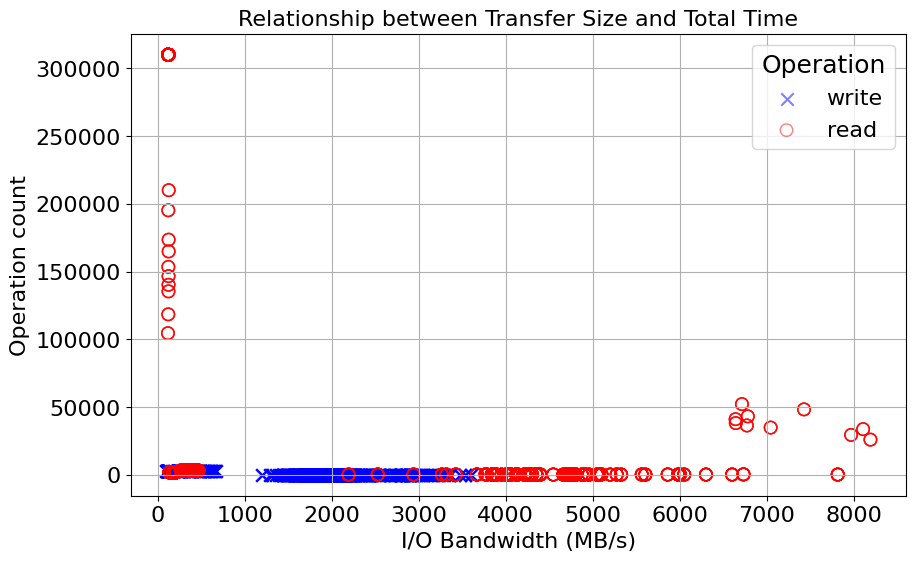

In [74]:
# Add new columns for colors and labels based on the 'operation' column
df['color'] = df['operation'].map({0: 'blue', 1: 'red'})
df['label'] = df['operation'].map({0: 'write', 1: 'read'})
df['marker'] = df['operation'].map({0: 'x', 1: 'o'})  # 'o' for circle, 's' for square

# 2D plot: Relationship between aggregateFilesizeMB and totalTime
plt.figure(figsize=(10, 6))

for label in df['label'].unique():
    subset = df[df['label'] == label]
    marker = subset['marker'].iloc[0]
    facecolor = 'none' if marker == 'o' else subset['color'].iloc[0]
    plt.scatter(subset['trMiB'], subset['opCount'], 
                label=label, 
                edgecolor=subset['color'].iloc[0],  # Edge color for circle markers
                facecolors=facecolor,  # Only the circle markers will be hollow
                marker=marker,
                s=80,
                alpha=0.5)

plt.title('Relationship between Transfer Size and Total Time')
plt.xlabel('I/O Bandwidth (MB/s)')
# plt.xlabel('Data size (MB)')
plt.ylabel('Operation count')
plt.grid(True)
plt.legend(title="Operation")
plt.show()


/tmp/ipykernel_39048/3775537900.py:10: UserWarning: You passed a edgecolor/edgecolors ('blue') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(subset['trMiB'], subset['opCount'], subset['aggregateFilesizeMB'],


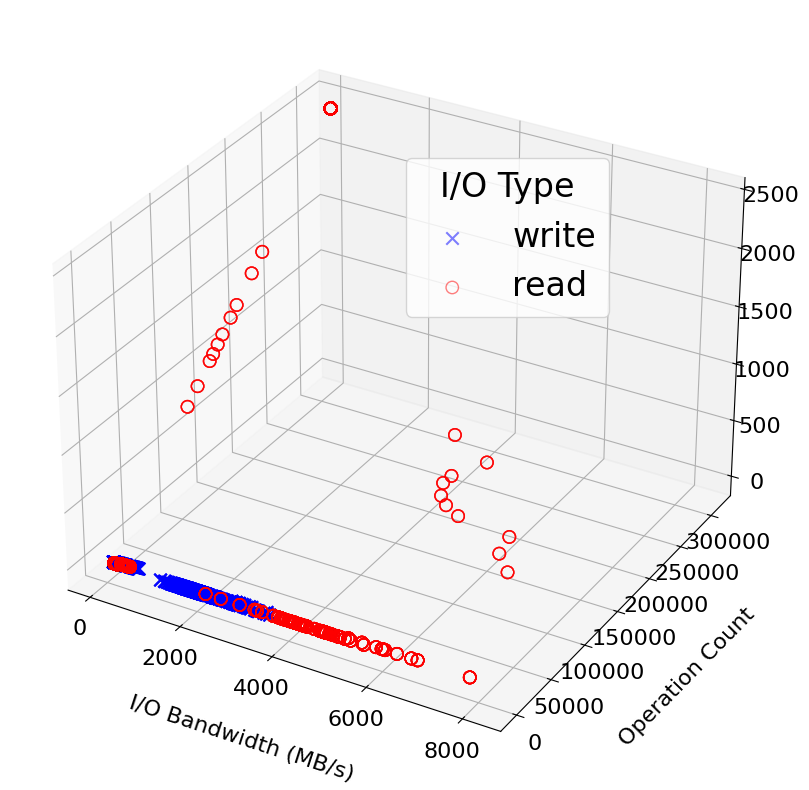

<Figure size 640x480 with 0 Axes>

In [75]:
# 3D plot: Relationship between aggregateFilesizeMB, totalTime, and trMiB
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')


for label in df['label'].unique():
    subset = df[df['label'] == label]
    marker = subset['marker'].iloc[0]
    facecolor = 'none' if marker == 'o' else subset['color'].iloc[0]
    ax.scatter(subset['trMiB'], subset['opCount'], subset['aggregateFilesizeMB'], 
                label=label, 
                edgecolor=subset['color'].iloc[0],  # Edge color for circle markers
                facecolors=facecolor,  # Only the circle markers will be hollow
                marker=marker,
                s=80,
                alpha=0.5)

# Set the font sizes for various plot elements
plt.rc('font', size=24)             # Default text size
plt.rc('axes', titlesize=24)        # Axes title font size
plt.rc('axes', labelsize=24)        # Axes label font size
plt.rc('xtick', labelsize=24)       # X-tick label font size
plt.rc('ytick', labelsize=24)       # Y-tick label font size
plt.rc('legend', fontsize=24)       # Legend font size
# plt.rc('figure', titlesize=18)      # Figure title font size

# ax.set_title('3D Relationship between operation count, flow size, and I/O bandwidth')
ax.set_xlabel('I/O Bandwidth (MB/s)', labelpad=20)
ax.set_ylabel('Operation Count', labelpad=23)
ax.set_zlabel('Flow Size (MB)', labelpad=20)
ax.legend(title="I/O Type", loc='best', bbox_to_anchor=(0, 0.83, 0.8, 0.0))

plt.figure(constrained_layout=True)
# fig.tight_layout()
plt.show()
fig.savefig(plot_file_name)

/tmp/ipykernel_39048/2229231784.py:10: UserWarning: You passed a edgecolor/edgecolors ('blue') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(subset['trMiB'], subset['stageOrder'], subset['aggregateFilesizeMB'],


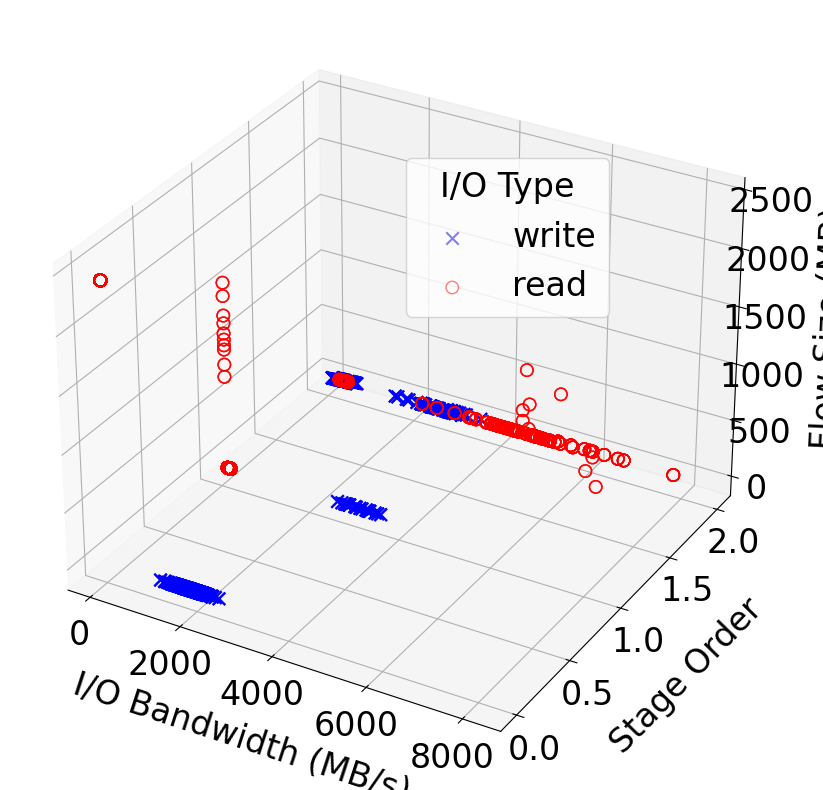

<Figure size 640x480 with 0 Axes>

In [76]:
# 3D plot: Relationship between aggregateFilesizeMB, totalTime, and trMiB
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')


for label in df['label'].unique():
    subset = df[df['label'] == label]
    marker = subset['marker'].iloc[0]
    facecolor = 'none' if marker == 'o' else subset['color'].iloc[0]
    ax.scatter(subset['trMiB'], subset['stageOrder'], subset['aggregateFilesizeMB'], 
                label=label, 
                edgecolor=subset['color'].iloc[0],  # Edge color for circle markers
                facecolors=facecolor,  # Only the circle markers will be hollow
                marker=marker,
                s=80,
                alpha=0.5)

# Set the font sizes for various plot elements
plt.rc('font', size=24)             # Default text size
plt.rc('axes', titlesize=24)        # Axes title font size
plt.rc('axes', labelsize=24)        # Axes label font size
plt.rc('xtick', labelsize=24)       # X-tick label font size
plt.rc('ytick', labelsize=24)       # Y-tick label font size
plt.rc('legend', fontsize=24)       # Legend font size
# plt.rc('figure', titlesize=18)      # Figure title font size

# ax.set_title('3D Relationship between operation count, flow size, and I/O bandwidth')
ax.set_xlabel('I/O Bandwidth (MB/s)', labelpad=20)
ax.set_ylabel('Stage Order', labelpad=23)
ax.set_zlabel('Flow Size (MB)', labelpad=20)
ax.legend(title="I/O Type", loc='best', bbox_to_anchor=(0, 0.83, 0.8, 0.0))

plt.figure(constrained_layout=True)
# fig.tight_layout()
plt.show()
fig.savefig(plot_file_name)

{'individuals': {'stage_order': 0, 'parallelism': 300, 'num_tasks': 300, 'predecessors': {'initial_data': {'inputs': ['ALL\\.chr.*\\.250000\\.vcf', 'columns\\.txt']}}, 'outputs': ['chr.*n-.*-.*\\.tar\\.gz']}, 'individuals_merge': {'stage_order': 1, 'parallelism': 10, 'num_tasks': 10, 'predecessors': {'individuals': {'inputs': ['chr.*n-.*-.*\\.tar\\.gz']}}, 'outputs': ['chr.*n\\.tar\\.gz']}, 'sifting': {'stage_order': 1, 'parallelism': 10, 'num_tasks': 10, 'predecessors': {'initial_data': {'inputs': ['ALL\\.chr([1-9]|10)\\.phase3_shapeit2_mvncall_integrated_v5\\.20130502\\.sites\\.annotation\\.vcf']}}, 'outputs': ['sifted.*\\.txt']}, 'mutation_overlap': {'stage_order': 2, 'parallelism': 10, 'num_tasks': 10, 'predecessors': {'initial_data': {'inputs': ['SAS', 'EAS', 'GBR', 'AMR', 'AFR', 'EUR', 'ALL', 'columns\\.txt']}, 'sifting': {'inputs': ['sifted.*\\.txt']}, 'individuals_merge': {'inputs': ['chr.*n\\.tar\\.gz']}}, 'outputs': ['chr\\d+-[A-Z]{3}\\.tar\\.gz$', 'chr\\d+-[A-Z]{3}\\.txt\\.t

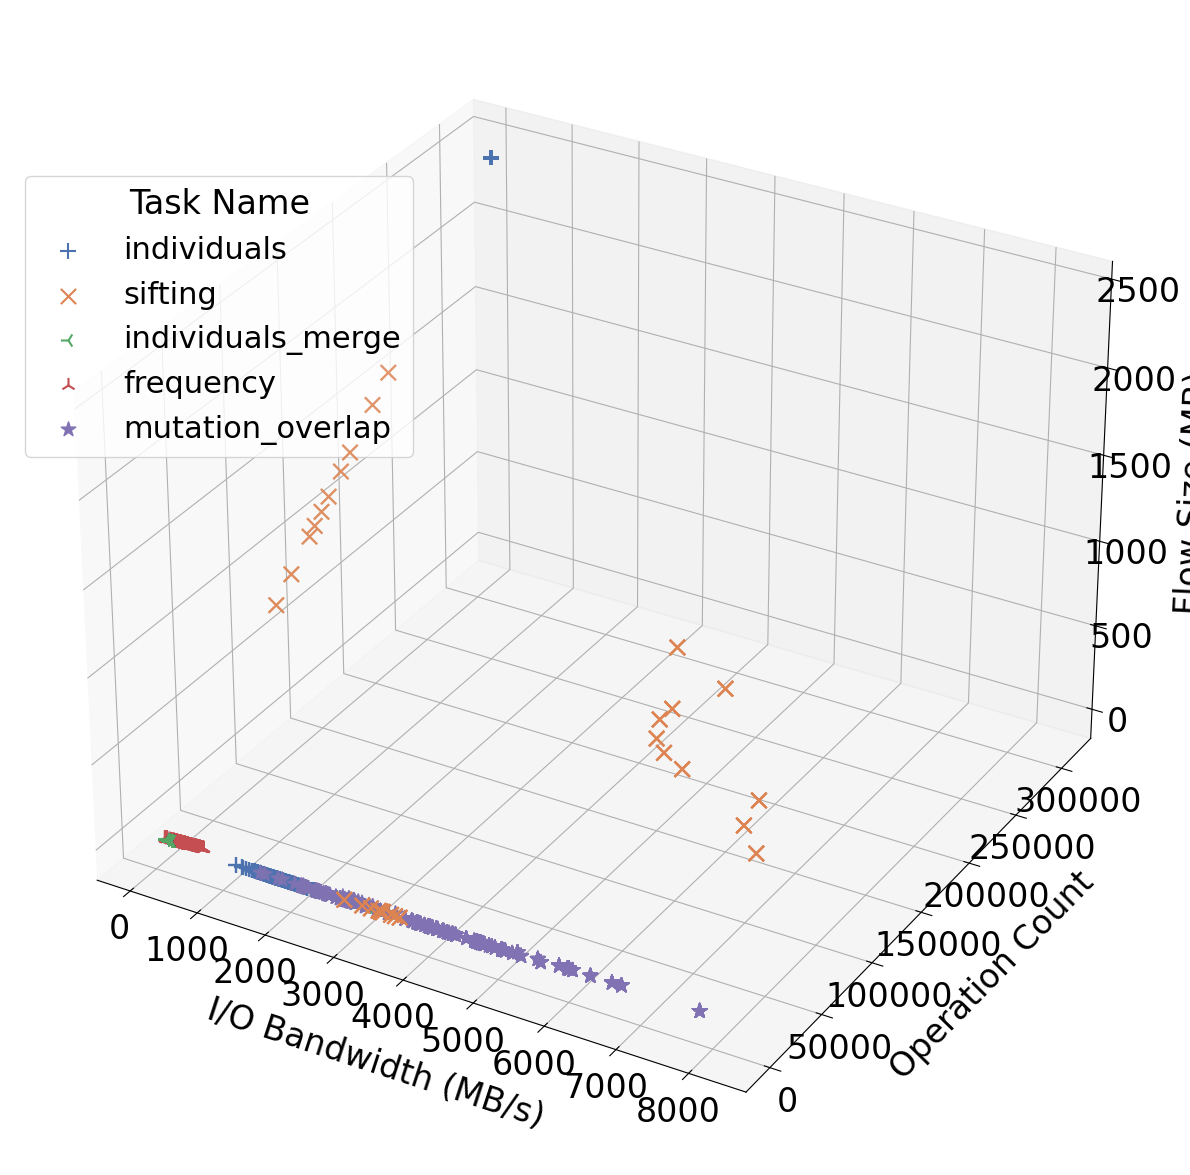

<Figure size 640x480 with 0 Axes>

In [77]:
import seaborn as sns
import json


# Load task ordering json file
task_order_dict = {}
with open(task_order_file) as f:
    task_order_dict = json.load(f)

print(task_order_dict)

# Ensure tasks are ordered based on task_order_dict
unique_tasks = sorted(
    df['taskName'].unique(), 
    key=lambda t: task_order_dict.get(t, {}).get('stage_order', float('inf'))
)

# Debugging output
print(f"Unique tasks: {unique_tasks}")  
if not unique_tasks:
    print("No tasks found, skipping plotting.")
    exit()

num_tasks = len(unique_tasks)

# Define color palette and markers
palette = sns.color_palette("deep", num_tasks)
# markers = ['+', 'x', '3', '2', '*', '^', 's', 'o', 'D', 'p', 'h']

# Split tasks into groups of 5
task_group_count = 5
task_groups = [unique_tasks[i:i+task_group_count] for i in range(0, num_tasks, task_group_count)]

for group_idx, task_group in enumerate(task_groups):


    # Filter out empty groups
    valid_tasks = [task for task in task_group if task in df['taskName'].values]
    print(f"Group {group_idx+1}: {valid_tasks}")
    if not valid_tasks:
        print(f"Skipping empty group {group_idx+1}")
        continue

    # 3D plot: Relationship between aggregateFilesizeMB, totalTime, and trMiB
    fig = plt.figure(figsize=(15, 15))
    ax = fig.add_subplot(111, projection='3d')

    x = df['trMiB']
    y = df['opCount']
    z = df['aggregateFilesizeMB']
    ax = fig.add_subplot(111, projection='3d')
    markers = ['+', 'x', '3', '2', '*']  # Add more markers as needed

    # Generate color and marker maps for current group
    color_map = {task: palette[i % len(palette)] for i, task in enumerate(valid_tasks)}
    marker_map = {task: markers[i % len(markers)] for i, task in enumerate(valid_tasks)}

    df['color'] = df['taskName'].map(lambda task: color_map.get(task, 'black'))  # Black if not found
    df['marker'] = df['taskName'].map(lambda task: marker_map.get(task, 'o'))  # 'o' if not found

    for task in valid_tasks:
        subset = df[df['taskName'] == task]
        if subset.empty:
            print(f"Skipping task '{task}' (no data)")
            continue

        ax.scatter(subset['trMiB'], subset['opCount'], subset['aggregateFilesizeMB'], 
                   label=task, 
                   color=color_map[task], 
                   marker=marker_map[task],
                   s=120)

    # Set labels and title
    plt.rc('font', size=24)
    plt.rc('axes', titlesize=24)
    plt.rc('axes', labelsize=24)
    plt.rc('xtick', labelsize=24)
    plt.rc('ytick', labelsize=24)
    plt.rc('legend', fontsize=22)

    ax.set_xlabel('I/O Bandwidth (MB/s)', labelpad=20)
    ax.set_ylabel('Operation Count', labelpad=23)
    ax.set_zlabel('Flow Size (MB)', labelpad=20)

    ax.legend(title="Task Name", loc="lower left", bbox_to_anchor=(0, 0.6, 1.3, 0.0))
    plt.figure(constrained_layout=True)

    plt.show()
    fig.savefig(f'taskColor_group{group_idx+1}_'+plot_file_name)


In [78]:
import re
import os

# # Function to extract the filename group
# def extract_group(filename):
#     for pattern in file_group_patterns:
#         if re.match(pattern, filename):
#             return re.split(r'\d', filename, 1)[0].rstrip('_')  # Extract text before first number
#     return "other"  # Default group
def extract_group(filename):
    if "_" in filename:
        # Keep the original method if the filename contains '_'
        for pattern in file_group_patterns:
            if re.match(pattern, filename):
                return re.split(r'\d', filename, 1)[0].rstrip('_')  # Extract text before first number
        return "other"  # Default group

    elif any(char.isdigit() for char in filename):
        # If the filename contains a number, split before the first number and keep the extension
        base, ext = filename.rsplit('.', 1) if '.' in filename else (filename, '')
        prefix = re.split(r'\d', base, 1)[0]
        return f"{prefix}.{ext}" if ext else prefix

    else:
        # If no underscore and no numbers, return the filename itself as the group
        return filename


# Add a new column to categorize file groups
df["file_group"] = df["fileName"].apply(extract_group)

# Check the unique file groups
print(f'Unique file groups: {df["file_group"].unique()}')


Unique file groups: ['chr.gz' 'ALL.chr.vcf' 'columns.txt' 'sifted.SIFT.chr.txt' 'ALL.chr']


Unique groups [5]: ['chr.gz' 'ALL.chr.vcf' 'columns.txt' 'sifted.SIFT.chr.txt' 'ALL.chr']


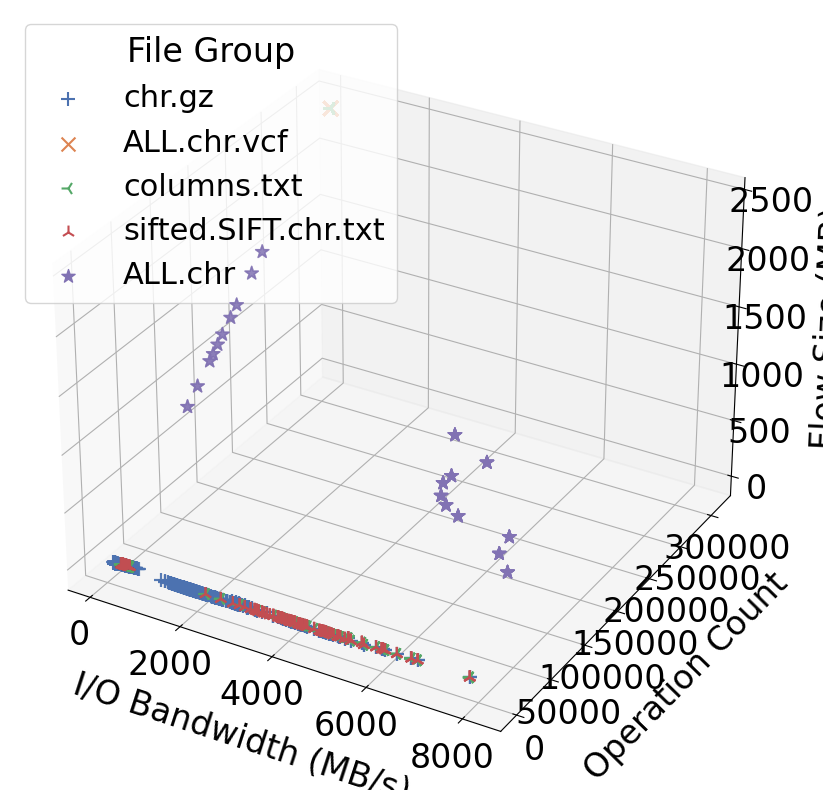

<Figure size 640x480 with 0 Axes>

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

# Generate a color palette
unique_groups = df["file_group"].unique()
print(f"Unique groups [{len(unique_groups)}]: {unique_groups}")

num_groups = len(unique_groups)

# Define color palette and markers
palette = sns.color_palette("deep", num_groups)
markers = ['+', 'x', '3', '2', '*', '^', 's', 'o', 'D', 'p', 'h']

# Split file groups into groups of n
file_group_count = 6
group_batches = [unique_groups[i:i+file_group_count] for i in range(0, num_groups, file_group_count)]

for batch_idx, group_batch in enumerate(group_batches):
    # Skip empty groups
    valid_groups = [group for group in group_batch if group in df["file_group"].values]
    if not valid_groups:
        print(f"Skipping empty group {batch_idx+1}")
        continue

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Generate color and marker maps for current group
    color_map = {group: palette[i % len(palette)] for i, group in enumerate(valid_groups)}
    marker_map = {group: markers[i % len(markers)] for i, group in enumerate(valid_groups)}

    # Assign colors and markers
    df["color"] = df["file_group"].map(lambda group: color_map.get(group, 'black'))
    df["marker"] = df["file_group"].map(lambda group: marker_map.get(group, 'o'))

    # Iterate through the valid file groups
    for group in valid_groups:
        subset = df[df["file_group"] == group]
        if subset.empty:
            print(f"Skipping group '{group}' (no data)")
            continue

        ax.scatter(subset['trMiB'], subset['opCount'], subset['aggregateFilesizeMB'], 
                   label=group, 
                   color=color_map[group],  
                   marker=marker_map[group],  
                   s=100)

    # Set font sizes
    plt.rc('font', size=24)
    plt.rc('axes', titlesize=24)
    plt.rc('axes', labelsize=24)
    plt.rc('xtick', labelsize=24)
    plt.rc('ytick', labelsize=24)
    plt.rc('legend', fontsize=22)

    # Set axis labels
    ax.set_xlabel('I/O Bandwidth (MB/s)', labelpad=20)
    ax.set_ylabel('Operation Count', labelpad=23)
    ax.set_zlabel('Flow Size (MB)', labelpad=20)

    # Legend updated to reflect file groups
    ax.legend(title="File Group", loc="lower left", bbox_to_anchor=(0, 0.6, 1.3, 0.0))
    

    plt.figure(constrained_layout=True)

    # Show and save figure
    plt.show()
    fig.savefig(f'fileColor_group{batch_idx+1}_'+plot_file_name)



Unique groups [5]: ['chr.gz' 'ALL.chr.vcf' 'columns.txt' 'sifted.SIFT.chr.txt' 'ALL.chr']


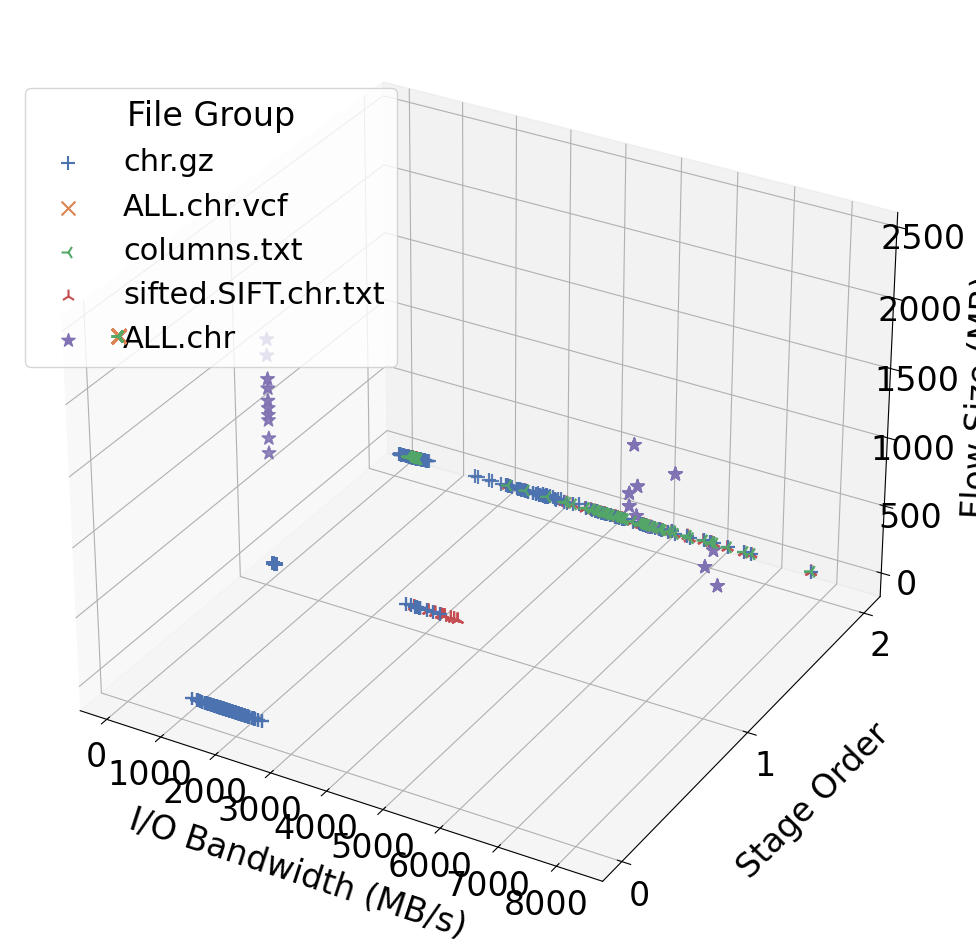

<Figure size 640x480 with 0 Axes>

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# Generate a color palette
unique_groups = df["file_group"].unique()
print(f"Unique groups [{len(unique_groups)}]: {unique_groups}")

num_groups = len(unique_groups)

# Define color palette and markers
palette = sns.color_palette("deep", num_groups)
markers = ['+', 'x', '3', '2', '*', '^', 's', 'o', 'D', 'p', 'h']

# Split file groups into groups of n
file_group_count = 6
group_batches = [unique_groups[i:i+file_group_count] for i in range(0, num_groups, file_group_count)]

for batch_idx, group_batch in enumerate(group_batches):
    # Skip empty groups
    valid_groups = [group for group in group_batch if group in df["file_group"].values]
    if not valid_groups:
        print(f"Skipping empty group {batch_idx+1}")
        continue

    fig = plt.figure(figsize=(12, 16))
    ax = fig.add_subplot(111, projection='3d')

    # Generate color and marker maps for current group
    color_map = {group: palette[i % len(palette)] for i, group in enumerate(valid_groups)}
    marker_map = {group: markers[i % len(markers)] for i, group in enumerate(valid_groups)}

    # Assign colors and markers
    df["color"] = df["file_group"].map(lambda group: color_map.get(group, 'black'))
    df["marker"] = df["file_group"].map(lambda group: marker_map.get(group, 'o'))

    # Iterate through the valid file groups
    for group in valid_groups:
        subset = df[df["file_group"] == group]
        if subset.empty:
            print(f"Skipping group '{group}' (no data)")
            continue

        ax.scatter(subset['trMiB'], subset['stageOrder'], subset['aggregateFilesizeMB'], 
                   label=group, 
                   color=color_map[group],  
                   marker=marker_map[group],  
                   s=100)

    # Set font sizes
    plt.rc('font', size=24)
    plt.rc('axes', titlesize=24)
    plt.rc('axes', labelsize=24)
    plt.rc('xtick', labelsize=24)
    plt.rc('ytick', labelsize=24)
    plt.rc('legend', fontsize=22)

    # Set axis labels
    ax.set_xlabel('I/O Bandwidth (MB/s)', labelpad=20)
    ax.set_ylabel('Stage Order', labelpad=23)
    ax.set_zlabel('Flow Size (MB)', labelpad=20)
    
    # Ensure y-axis only shows integers
    ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    # Legend updated to reflect file groups
    ax.legend(title="File Group", loc="lower left", bbox_to_anchor=(0, 0.6, 1.3, 0.0))

    plt.figure(constrained_layout=True)

    # Show and save figure
    plt.show()
    fig.savefig(f'fileColor_group{batch_idx+1}_'+plot_file_name)



In [81]:
print(unique_groups)

['chr.gz' 'ALL.chr.vcf' 'columns.txt' 'sifted.SIFT.chr.txt' 'ALL.chr']


/tmp/ipykernel_39048/1379120826.py:45: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.4, wspace=0.4)


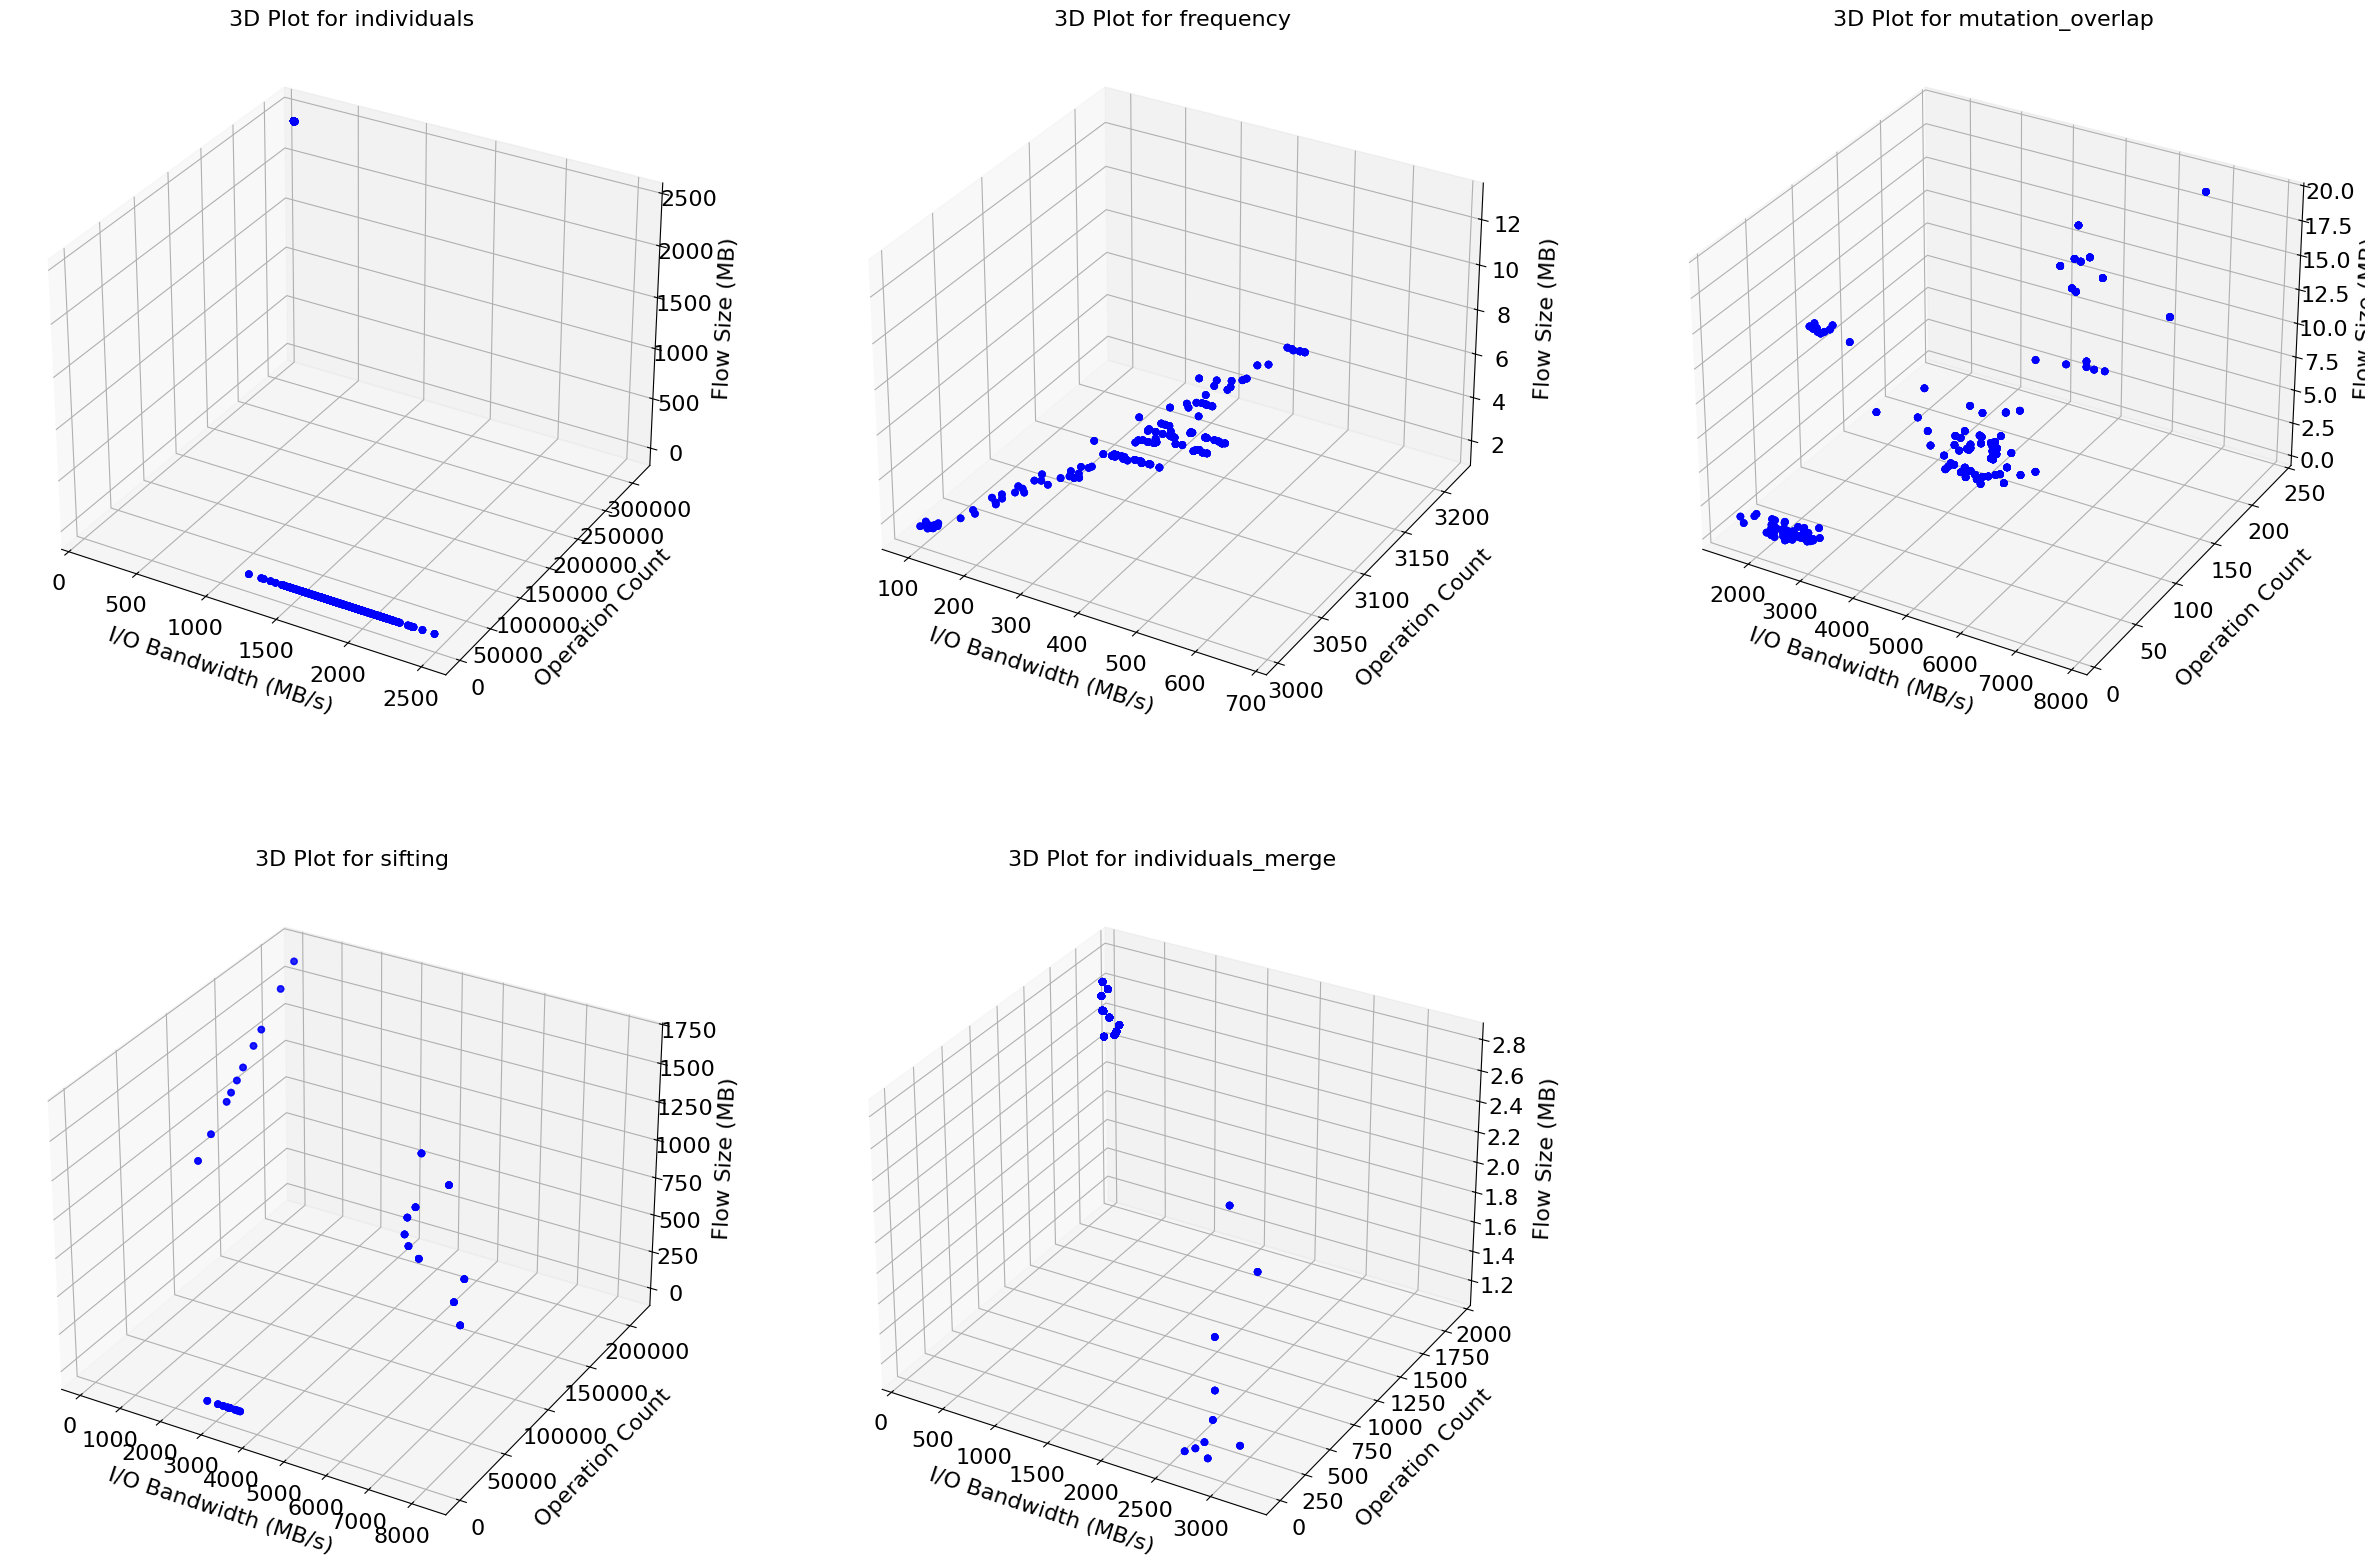

<Figure size 640x480 with 0 Axes>

In [82]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

x = df['trMiB']
y = df['opCount']
z = df['aggregateFilesizeMB']

# Generate a color palette
unique_tasks = df['taskName'].unique()
num_tasks = len(unique_tasks)

# Set the font sizes for various plot elements
plt.rc('font', size=18)             # Default text size
plt.rc('axes', titlesize=16)        # Axes title font size
plt.rc('axes', labelsize=16)        # Axes label font size
plt.rc('xtick', labelsize=16)       # X-tick label font size
plt.rc('ytick', labelsize=16)       # Y-tick label font size
plt.rc('legend', fontsize=16)       # Legend font size

# Determine the grid layout based on the number of tasks
num_cols = min(3, num_tasks)  # Max 3 columns per row
num_rows = int(np.ceil(num_tasks / num_cols))  # Calculate required rows

# Create a figure and define the GridSpec
fig = plt.figure(figsize=(num_cols * 10, num_rows * 10))
gs = gridspec.GridSpec(num_rows, num_cols)

# Generate grid positions dynamically
task_indices = [(i // num_cols, i % num_cols) for i in range(num_tasks)]

for i, (task, (row, col)) in enumerate(zip(unique_tasks, task_indices)):
    subset = df[df['taskName'] == task]
    ax = fig.add_subplot(gs[row, col], projection='3d')
    ax.scatter(subset['trMiB'], subset['opCount'], subset['aggregateFilesizeMB'], 
               label=task, 
               color='b')
    ax.set_title(f'3D Plot for {task}')
    ax.set_xlabel('I/O Bandwidth (MB/s)', labelpad=10)
    ax.set_ylabel('Operation Count', labelpad=13)
    ax.set_zlabel('Flow Size (MB)', labelpad=10)

plt.figure(constrained_layout=True)
plt.subplots_adjust(hspace=0.4, wspace=0.4) 
plt.show()
fig.savefig('tasksubplot_' + plot_file_name)

/tmp/ipykernel_39048/1905716732.py:41: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.4, wspace=0.4)


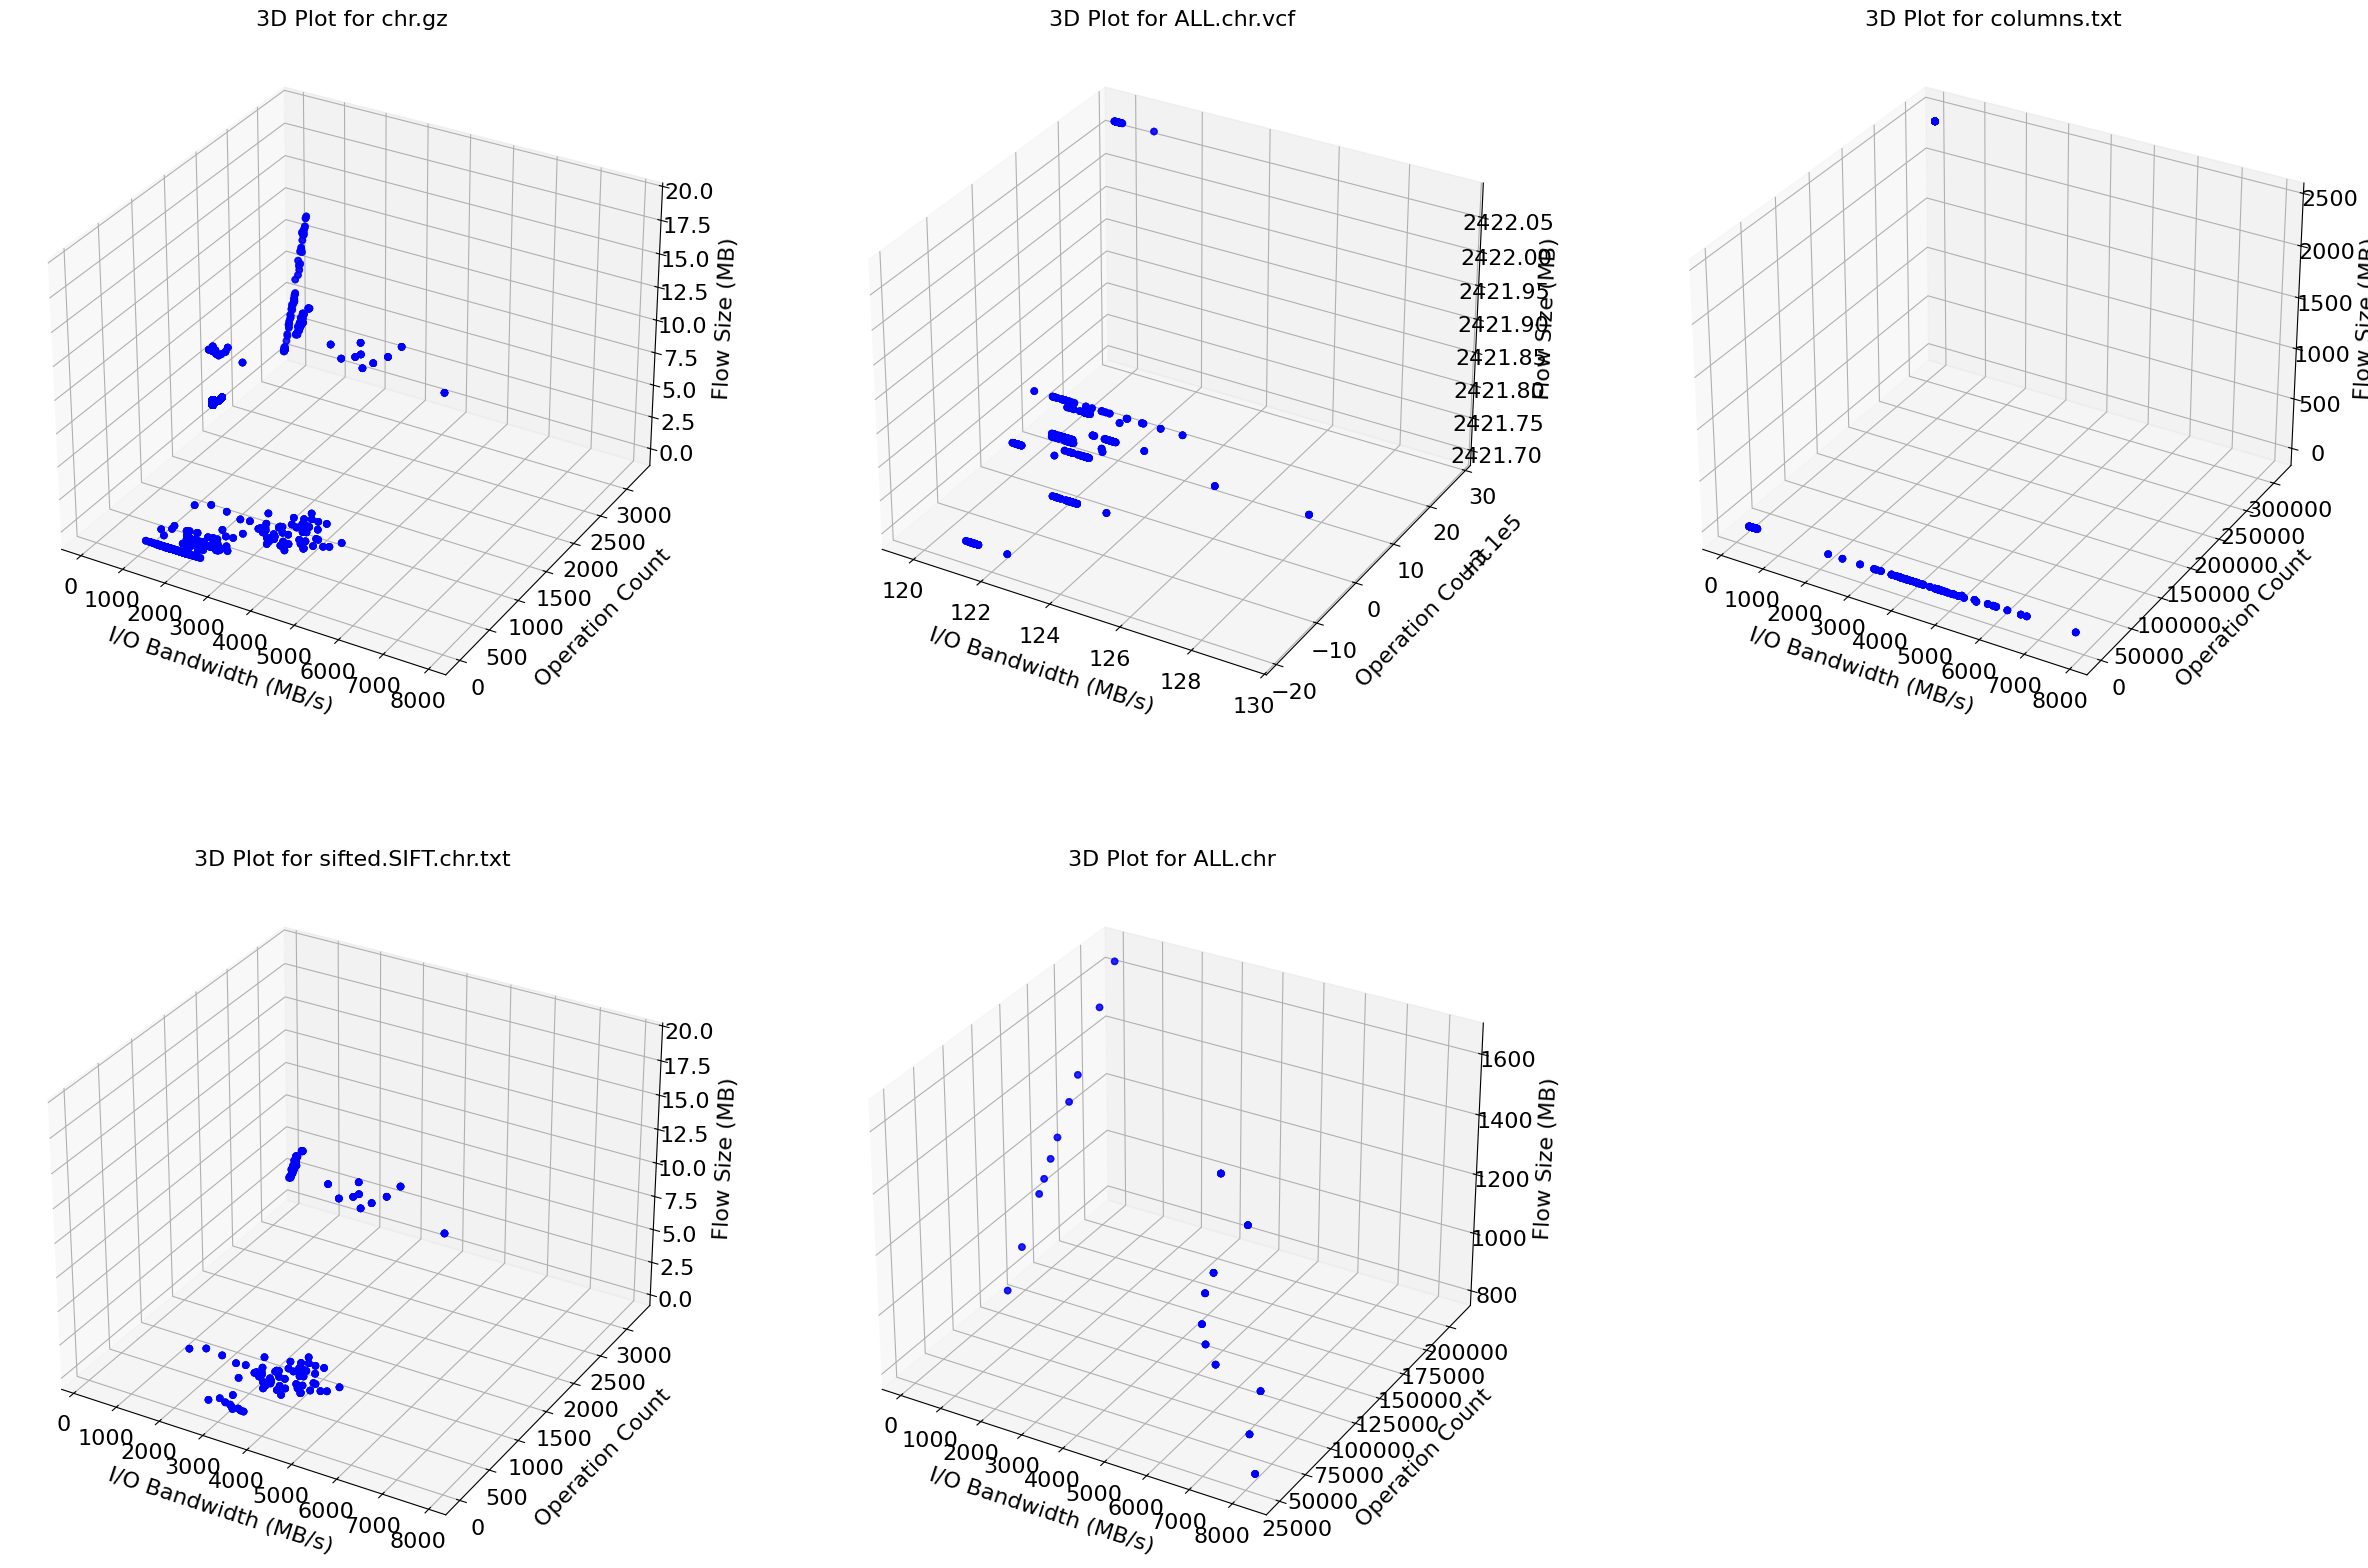

<Figure size 640x480 with 0 Axes>

In [83]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# Generate a color palette
unique_filegroup = df['file_group'].unique()
num_filegroups = len(unique_filegroup)

# Set the font sizes for various plot elements
plt.rc('font', size=18)             # Default text size
plt.rc('axes', titlesize=16)        # Axes title font size
plt.rc('axes', labelsize=16)        # Axes label font size
plt.rc('xtick', labelsize=16)       # X-tick label font size
plt.rc('ytick', labelsize=16)       # Y-tick label font size
plt.rc('legend', fontsize=16)       # Legend font size

# Determine the grid layout based on the number of unique file groups
num_cols = min(3, num_filegroups)  # Max 3 columns per row
num_rows = int(np.ceil(num_filegroups / num_cols))  # Calculate required rows

# Create a figure and define the GridSpec
fig = plt.figure(figsize=(num_cols * 10, num_rows * 10))
gs = gridspec.GridSpec(num_rows, num_cols)

# Generate grid positions dynamically
task_indices = [(i // num_cols, i % num_cols) for i in range(num_filegroups)]

for i, (file, (row, col)) in enumerate(zip(unique_filegroup, task_indices)):
    subset = df[df['file_group'] == file]
    ax = fig.add_subplot(gs[row, col], projection='3d')
    ax.scatter(subset['trMiB'], subset['opCount'], subset['aggregateFilesizeMB'], 
               label=file, 
               color='b')
    ax.set_title(f'3D Plot for {file}')
    ax.set_xlabel('I/O Bandwidth (MB/s)', labelpad=10)
    ax.set_ylabel('Operation Count', labelpad=13)
    ax.set_zlabel('Flow Size (MB)', labelpad=10)

plt.figure(constrained_layout=True)
plt.subplots_adjust(hspace=0.4, wspace=0.4) 
plt.show()
fig.savefig('tasksubplot_' + plot_file_name)


/tmp/ipykernel_39048/4216481997.py:42: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  plt.subplots_adjust(hspace=0.4, wspace=0.4)


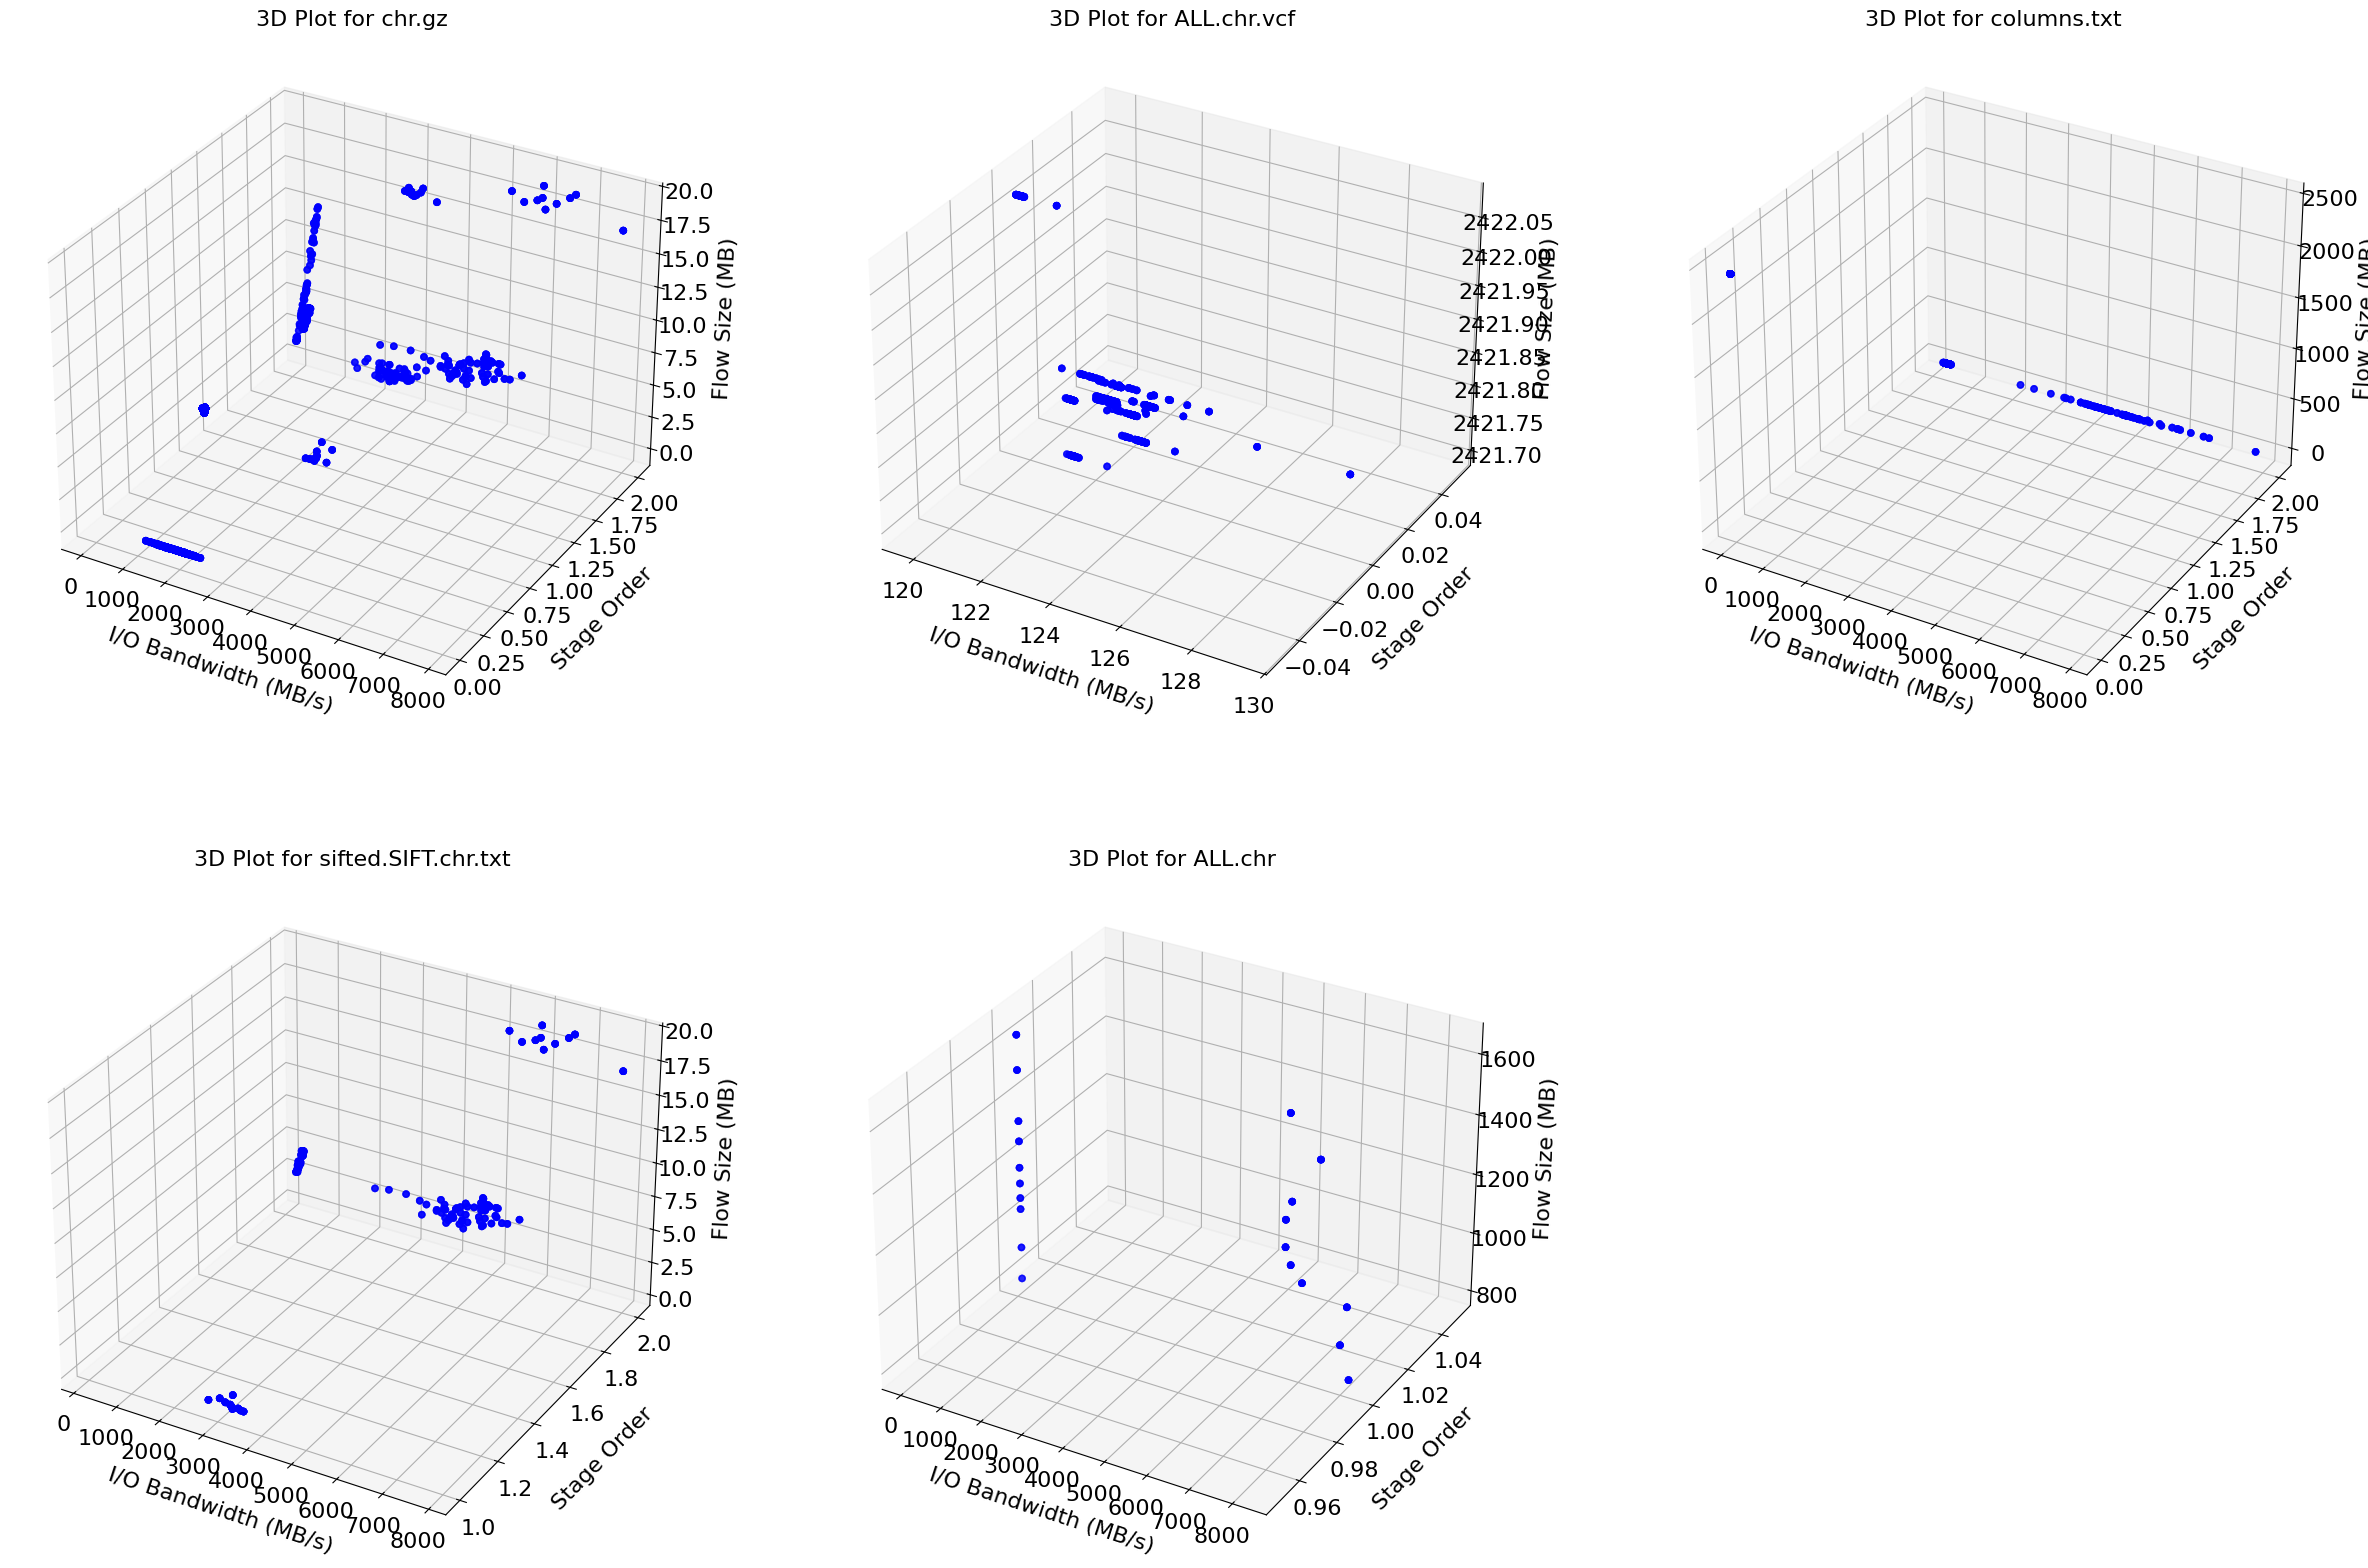

<Figure size 640x480 with 0 Axes>

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np


# Generate a color palette
unique_filegroup = df['file_group'].unique()
num_filegroups = len(unique_filegroup)

# Set the font sizes for various plot elements
plt.rc('font', size=18)             # Default text size
plt.rc('axes', titlesize=16)        # Axes title font size
plt.rc('axes', labelsize=16)        # Axes label font size
plt.rc('xtick', labelsize=16)       # X-tick label font size
plt.rc('ytick', labelsize=16)       # Y-tick label font size
plt.rc('legend', fontsize=16)       # Legend font size

# Determine the grid layout based on the number of unique file groups
num_cols = min(3, num_filegroups)  # Max 3 columns per row
num_rows = int(np.ceil(num_filegroups / num_cols))  # Calculate required rows

# Create a figure and define the GridSpec
fig = plt.figure(figsize=(num_cols * 10, num_rows * 10))
gs = gridspec.GridSpec(num_rows, num_cols)

# Generate grid positions dynamically
task_indices = [(i // num_cols, i % num_cols) for i in range(num_filegroups)]

for i, (file, (row, col)) in enumerate(zip(unique_filegroup, task_indices)):
    subset = df[df['file_group'] == file]
    ax = fig.add_subplot(gs[row, col], projection='3d')
    ax.scatter(subset['trMiB'], subset['stageOrder'], subset['aggregateFilesizeMB'], 
               label=file, 
               color='b')
    ax.set_title(f'3D Plot for {file}')
    ax.set_xlabel('I/O Bandwidth (MB/s)', labelpad=10)
    ax.set_ylabel('Stage Order', labelpad=13)
    ax.set_zlabel('Flow Size (MB)', labelpad=10)

plt.figure(constrained_layout=True)
plt.subplots_adjust(hspace=0.4, wspace=0.4) 
plt.show()
fig.savefig('tasksubplot_' + plot_file_name)

In [85]:
df.columns, df['stageOrder'].unique()

(Index(['operation', 'randomOffset', 'transferSize', 'aggregateFilesizeMB',
        'numTasks', 'parallelism', 'totalTime', 'numNodesList', 'numNodes',
        'tasksPerNode', 'trMiB', 'storageType', 'opCount', 'taskName',
        'taskPID', 'fileName', 'stageOrder', 'prevTask', 'color', 'label',
        'marker', 'file_group'],
       dtype='object'),
 array([0, 2, 1]))